<a href="https://colab.research.google.com/github/Suhasri28/SDC-Activities/blob/main/Spam_detection_deep_learning_algorithms.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
Spam detection

In [1]:
!pip install scikit-learn pandas nltk


In [3]:
import pandas as pd
import nltk
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Step 1: Download NLTK data (if you haven't already)
nltk.download('stopwords')

# Step 2: Load your dataset
# Here we are using an example dataset (you can replace this with your own dataset)
# You can use a dataset with columns ['message', 'label'], where 'label' is either 'spam' or 'ham' (non-spam)
# Dataset: You can find public datasets online or create your own CSV with messages and labels.

data = {
    'message': [
        'Congratulations, you won a lottery of 1 million dollars!',
        'Hi, how are you? I wanted to talk about the meeting.',
        'Get your free prize today! Call now.',
        'Just checking in to see if you received my last email.',
        'Limited time offer! Buy one get one free.',
        'Hey, can we reschedule our call to 3 pm tomorrow?'
    ],
    'label': ['spam', 'ham', 'spam', 'ham', 'spam', 'ham']
}

# Convert the data into a pandas DataFrame
df = pd.DataFrame(data)

# Step 3: Prepare features and labels
X = df['message']
y = df['label']

# Step 4: Text vectorization (Convert text to numerical data)
vectorizer = TfidfVectorizer(stop_words=nltk.corpus.stopwords.words('english'))
X_tfidf = vectorizer.fit_transform(X)

# Step 5: Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.3, random_state=42)

# Step 6: Train a Naive Bayes model
model = MultinomialNB()
model.fit(X_train, y_train)

# Step 7: Test the model
y_pred = model.predict(X_test)

# Step 8: Evaluate the model
print("Classification Report:\n", classification_report(y_test, y_pred))

# Example prediction
sample_message = input("Enter a message to predict (spam/ham): ")
sample_tfidf = vectorizer.transform([sample_message])
prediction = model.predict(sample_tfidf)
print(f"Prediction: {prediction[0]}")


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _

Classification Report:
               precision    recall  f1-score   support

         ham       0.50      1.00      0.67         1
        spam       0.00      0.00      0.00         1

    accuracy                           0.50         2
   macro avg       0.25      0.50      0.33         2
weighted avg       0.25      0.50      0.33         2

Enter a message to predict (spam/ham): I'm eating food
Prediction: ham


In [ ]:
Image Classifier

In [4]:
!pip install tensorflow


In [6]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
import matplotlib.pyplot as plt

# Step 1: Load the CIFAR-10 dataset (or replace it with your own dataset)
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Step 2: Preprocess the data
# Normalize pixel values to be between 0 and 1
x_train, x_test = x_train / 255.0, x_test / 255.0

# Step 3: Build the CNN model
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10)  # 10 classes for CIFAR-10
])

# Step 4: Compile the model
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

# Step 5: Train the model
model.fit(x_train, y_train, epochs=10, validation_data=(x_test, y_test))

# Step 6: Evaluate the model
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f"Test accuracy: {test_acc}")

# Step 7: Make predictions
predictions = model.predict(x_test)

# Example: Display an image and its prediction
plt.imshow(x_test[0])
plt.title(f"Predicted: {predictions[0].argmax()}")
plt.show()


Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 84s 53ms/step - accuracy: 0.3443 - loss: 1.7543 - val_accuracy: 0.5599 - val_loss: 1.2116
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 124s 41ms/step - accuracy: 0.5882 - loss: 1.1624 - val_accuracy: 0.6360 - val_loss: 1.0313
Epoch 3/10


KeyboardInterrupt: 

In [7]:
!pip install gradio


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 MB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.2/322.2 kB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.2/95.2 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 67.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.4/62.4 kB 4.3 MB/s eta 0:00:00


In [8]:
import tensorflow as tf
import numpy as np
import gradio as gr
from tensorflow.keras.preprocessing import image

# Load CIFAR-10 labels
labels = ['Airplane', 'Car', 'Bird', 'Cat', 'Deer', 'Dog', 'Frog', 'Horse', 'Ship', 'Truck']

# Load CIFAR-10 model or define one (Here we define for demo)
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(10)
])

# Compile & train quickly (for testing purposes)
(x_train, y_train), _ = tf.keras.datasets.cifar10.load_data()
x_train = x_train / 255.0
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

model.fit(x_train, y_train, epochs=1)  # Just 1 epoch for quick load

# Function to classify uploaded image
def classify(img):
    img = image.smart_resize(img, (32, 32))
    img = np.expand_dims(img, axis=0) / 255.0
    pred = model.predict(img)
    class_index = np.argmax(pred)
    return labels[class_index]

# Gradio interface
interface = gr.Interface(
    fn=classify,
    inputs=gr.Image(type="numpy"),
    outputs="label",
    title="CIFAR-10 Image Classifier",
    description="Upload an image and get the predicted class!"
)

interface.launch()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 58s 36ms/step - accuracy: 0.3840 - loss: 1.6820
Running Gradio in a Colab notebook requires sharing enabled. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://b71dac6893c980bcde.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [9]:
pip install tensorflow gradio pillow


In [10]:
import gradio as gr
import tensorflow as tf
from tensorflow.keras.applications.mobilenet_v2 import (
    MobileNetV2,
    decode_predictions,
    preprocess_input
)
from tensorflow.keras.preprocessing import image
import numpy as np
from PIL import Image

# Load the pretrained MobileNetV2 model
model = MobileNetV2(weights="imagenet")

# Function to process and predict
def classify_image(img: Image.Image):
    img = img.resize((224, 224))  # Resize to model's expected input
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)

    predictions = model.predict(img_array)
    decoded = decode_predictions(predictions, top=3)[0]

    # Format output
    results = {label: float(score) for (_, label, score) in decoded}
    return results

# Build Gradio Interface
interface = gr.Interface(
    fn=classify_image,
    inputs=gr.Image(type="pil"),
    outputs=gr.Label(num_top_classes=3),
    title="📸 Real-World Image Classifier",
    description="Upload an image and this model will classify it using MobileNetV2 (pretrained on ImageNet)."
)

# Launch the app
interface.launch()


14536120/14536120 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Running Gradio in a Colab notebook requires sharing enabled. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://b6f8baaf114ead24ef.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


ANN

In [11]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize the input data
x_train, x_test = x_train / 255.0, x_test / 255.0

# One-hot encode the labels
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

# Build ANN model
model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')  # 10 classes (digits 0–9)
])

# Compile model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train the model
model.fit(x_train, y_train, epochs=5, validation_split=0.2)

# Evaluate the model
loss, accuracy = model.evaluate(x_test, y_test)
print(f"Test Accuracy: {accuracy:.2f}")

# Predict a single digit
import numpy as np
sample = np.expand_dims(x_test[0], axis=0)
prediction = model.predict(sample)
predicted_digit = prediction.argmax()

print(f"Predicted digit: {predicted_digit}")


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8673 - loss: 0.4647 - val_accuracy: 0.9538 - val_loss: 0.1601
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9647 - loss: 0.1196 - val_accuracy: 0.9687 - val_loss: 0.1069
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9778 - loss: 0.0753 - val_accuracy: 0.9728 - val_loss: 0.0947
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.9833 - loss: 0.0538 - val_accuracy: 0.9736 - val_loss: 0.0917
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.9863 - loss: 0.0427 - val_accuracy: 0.9703 - val_loss: 0.1007
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9710 - loss: 0.1002
Test Accuracy: 0.97


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
Predicted digit: 7


CNN


In [12]:
!pip install tensorflow



In [13]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

# 📥 Load and preprocess the data
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Reshape for CNN: (samples, height, width, channels)
x_train = x_train.reshape(-1, 28, 28, 1).astype("float32") / 255.0
x_test = x_test.reshape(-1, 28, 28, 1).astype("float32") / 255.0

# One-hot encode the labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# 🧱 Build the CNN model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),  # Helps prevent overfitting
    Dense(10, activation='softmax')  # 10 digit classes
])

# 🛠️ Compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# 🚀 Train the model
model.fit(x_train, y_train, epochs=5, validation_split=0.2, batch_size=128)

# 🎯 Evaluate
loss, accuracy = model.evaluate(x_test, y_test)
print(f"\n✅ Test accuracy: {accuracy:.4f}")

# 🔍 Predict one sample
import numpy as np
sample = np.expand_dims(x_test[0], axis=0)
prediction = model.predict(sample)
print(f"Predicted digit: {prediction.argmax()}")


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 59s 135ms/step - accuracy: 0.7785 - loss: 0.7086 - val_accuracy: 0.9783 - val_loss: 0.0778
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 35s 94ms/step - accuracy: 0.9635 - loss: 0.1169 - val_accuracy: 0.9852 - val_loss: 0.0537
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 41s 95ms/step - accuracy: 0.9751 - loss: 0.0844 - val_accuracy: 0.9864 - val_loss: 0.0481
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 40s 92ms/step - accuracy: 0.9795 - loss: 0.0671 - val_accuracy: 0.9871 - val_loss: 0.0465
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 41s 93ms/step - accuracy: 0.9840 - loss: 0.0511 - val_accuracy: 0.9878 - val_loss: 0.0400
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9875 - loss: 0.0367



✅ Test accuracy: 0.9899
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
Predicted digit: 7


In [14]:
!pip install tensorflow matplotlib opencv-python


In [16]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input, decode_predictions
from tensorflow.keras.preprocessing import image
from PIL import Image
import gradio as gr

# Load pre-trained model
model = MobileNetV2(weights="imagenet")

# Prediction function
def classify_image(img):
    img = img.resize((224, 224))
    img_array = image.img_to_array(img)
    img_batch = np.expand_dims(img_array, axis=0)
    img_preprocessed = preprocess_input(img_batch)
    preds = model.predict(img_preprocessed)
    results = decode_predictions(preds, top=3)[0]
    return {label: float(f"{prob*100:.2f}") for (_, label, prob) in results}

# Gradio interface
interface = gr.Interface(
    fn=classify_image,
    inputs=gr.Image(type="pil", label="Upload an Image"),
    outputs=gr.Label(num_top_classes=3),
    title="📸 Image Classifier",
    description="Upload an image and get the top 3 predicted objects with confidence levels.",
    allow_flagging="never"
)

interface.launch()



/usr/local/lib/python3.11/dist-packages/gradio/interface.py:415: UserWarning: The `allow_flagging` parameter in `Interface` is deprecated.Use `flagging_mode` instead.
  warnings.warn(


Running Gradio in a Colab notebook requires sharing enabled. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://65e7e8c55ee3baa1ee.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


RNN

In [17]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Sample training data
corpus = [
    "I love machine learning",
    "I love deep learning",
    "I enjoy learning new things",
    "Machine learning is powerful",
    "Deep learning is a part of AI"
]

# Tokenize the text
tokenizer = Tokenizer()
tokenizer.fit_on_texts(corpus)
total_words = len(tokenizer.word_index) + 1

# Generate sequences
input_sequences = []
for line in corpus:
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

# Pad sequences
max_sequence_len = max([len(x) for x in input_sequences])
input_sequences = np.array(pad_sequences(input_sequences, maxlen=max_sequence_len, padding='pre'))

# Split predictors and label
X = input_sequences[:, :-1]
y = input_sequences[:, -1]

# One-hot encode output
y = tf.keras.utils.to_categorical(y, num_classes=total_words)

# Build RNN model
model = Sequential()
model.add(Embedding(total_words, 10, input_length=max_sequence_len - 1))
model.add(SimpleRNN(100))
model.add(Dense(total_words, activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

# Train the model
model.fit(X, y, epochs=200, verbose=1)

# ✨ Function to generate text
def generate_next_words(seed_text, next_words=3):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_sequence_len - 1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)
        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

# 🔍 Try it out
print(generate_next_words("I love", 3))


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.0526 - loss: 2.7091
Epoch 2/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.1053 - loss: 2.6793
Epoch 3/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - accuracy: 0.1579 - loss: 2.6502
Epoch 4/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step - accuracy: 0.3158 - loss: 2.6200
Epoch 5/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 361ms/step - accuracy: 0.2632 - loss: 2.5873
Epoch 6/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 558ms/step - accuracy: 0.2632 - loss: 2.5508
Epoch 7/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - accuracy: 0.2632 - loss: 2.5099
Epoch 8/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 325ms/step - accuracy: 0.2632 - loss: 2.4647
Epoch 9/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step - accuracy: 0.2632 - loss: 2.4166
Epoch 10/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - accuracy: 0.2632 - loss: 2.3695
Epoch 11/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step - accuracy: 0.2632 - loss: 2.3300
Epoch 12/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - accuracy: 0.2

In [18]:
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense
from tensorflow.keras.preprocessing.sequence import pad_sequences

# 🍿 Load the IMDb dataset
vocab_size = 10000  # Only keep top 10,000 words
maxlen = 500  # Pad all sequences to length 500
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)

# 🧼 Pad sequences
x_train = pad_sequences(x_train, maxlen=maxlen)
x_test = pad_sequences(x_test, maxlen=maxlen)

# 🏗️ Build the model
model = Sequential()
model.add(Embedding(vocab_size, 32, input_length=maxlen))
model.add(SimpleRNN(64))
model.add(Dense(1, activation='sigmoid'))  # Binary classification

# ⚙️ Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

# 🏋️ Train the model
model.fit(x_train, y_train, epochs=5, batch_size=64, validation_split=0.2)

# 🧪 Evaluate
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"\n🎯 Test Accuracy: {test_acc:.2f}")


17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 66s 204ms/step - accuracy: 0.5520 - loss: 0.6730 - val_accuracy: 0.7302 - val_loss: 0.5338
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 71s 167ms/step - accuracy: 0.8264 - loss: 0.4013 - val_accuracy: 0.8140 - val_loss: 0.4531
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 75s 147ms/step - accuracy: 0.8612 - loss: 0.3398 - val_accuracy: 0.8070 - val_loss: 0.4369
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 83s 149ms/step - accuracy: 0.8538 - loss: 0.3406 - val_accuracy: 0.8112 - val_loss: 0.4796
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 83s 153ms/step - accuracy: 0.9087 - loss: 0.2392 - val_accuracy: 0.8152 - val_loss: 0.4273
782/782 ━━━━━━━━━━━━━━━━━━━━ 20s 26ms/step - accuracy: 0.8161 - loss: 0.4205

🎯 Test Accuracy: 0.82


In [ ]:
LSTM for sentimemt analysis

In [19]:
!pip install yfinance pandas numpy matplotlib tensorflow


YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


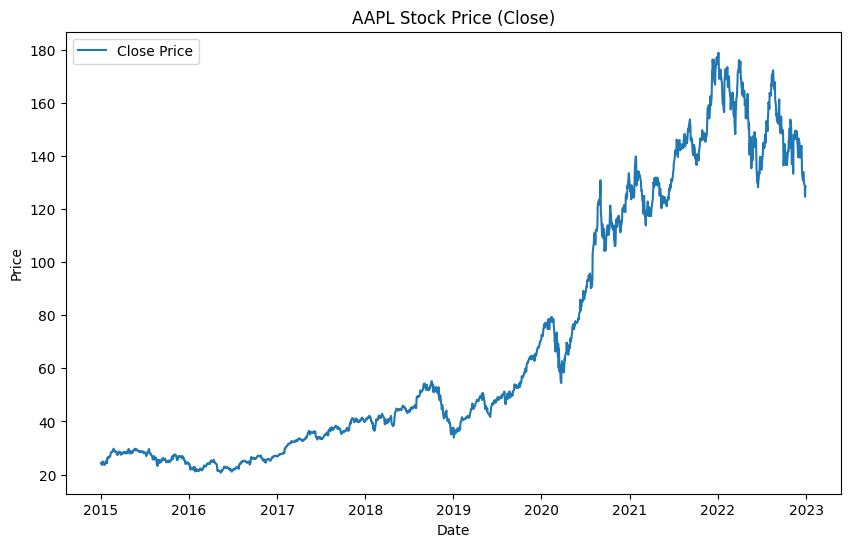

Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 0.2734
Epoch 2/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0397
Epoch 3/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0161
Epoch 4/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 5.8830e-04
Epoch 5/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 4.8704e-04
Epoch 6/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 5.9289e-04
Epoch 7/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 4.8960e-04
Epoch 8/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 5.3315e-04
Epoch 9/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 3.9708e-04
Epoch 10/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 3.9057e-04
Epoch 11/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 4.6426e-04
Epoch 12/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 3.4290e-04
Epoch 13/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 4.4551e-04
Epoch 14/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 5.6686e-04
Epoch 15/20
62/62 ━━━━━━━━━━━━━━━━━━━━

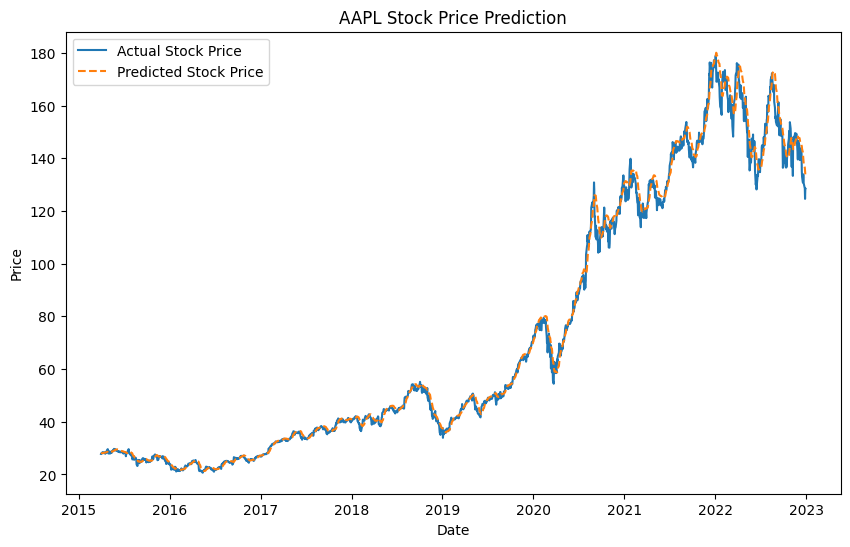

In [20]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator
from sklearn.preprocessing import MinMaxScaler

# 🔥 Load Stock Data using Yahoo Finance
stock_symbol = 'AAPL'  # You can change this to any stock symbol
start_date = '2015-01-01'
end_date = '2023-01-01'

data = yf.download(stock_symbol, start=start_date, end=end_date)

# 📊 Plot closing price
plt.figure(figsize=(10, 6))
plt.plot(data['Close'], label="Close Price")
plt.title(f'{stock_symbol} Stock Price (Close)')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

# 🧼 Normalize the data (Min-Max scaling)
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data['Close'].values.reshape(-1, 1))

# 🧳 Prepare the data for LSTM (using TimeseriesGenerator)
n_input = 60  # Number of previous days to predict the next day

generator = TimeseriesGenerator(scaled_data, scaled_data, length=n_input, batch_size=32)

# 🏗️ Build the LSTM model
model = Sequential()
model.add(LSTM(50, activation='relu', input_shape=(n_input, 1)))
model.add(Dense(1))

# ⚙️ Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# 🏋️ Train the model
model.fit(generator, epochs=20)

# 📈 Predict future stock prices
predicted_stock_price = model.predict(generator)

# 🧮 Inverse scaling
predicted_stock_price = scaler.inverse_transform(predicted_stock_price)

# 🔍 Plot the results
plt.figure(figsize=(10, 6))
plt.plot(data.index[n_input:], data['Close'][n_input:], label="Actual Stock Price")
plt.plot(data.index[n_input:], predicted_stock_price, label="Predicted Stock Price", linestyle='--')
plt.title(f'{stock_symbol} Stock Price Prediction')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 322ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/backend/tensorflow/trainer.py:82: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


0/10000 [D loss: 0.6841896772384644 | D accuracy: 52.34375] [G loss: 0.6929454803466797]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step


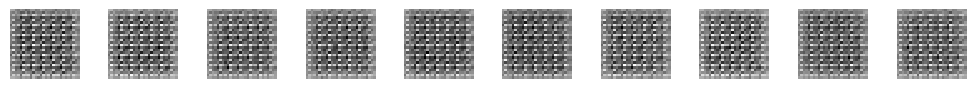

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
1/10000 [D loss: 0.6839509010314941 | D accuracy: 47.786460876464844] [G loss: 0.6889784336090088]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
2/10000 [D loss: 0.6862834692001343 | D accuracy: 44.94791793823242] [G loss: 0.6824647784233093]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
3/10000 [D loss: 0.6897519826889038 | D accuracy: 42.04798889160156] [G loss: 0.6731351017951965]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
4/10000 [D loss: 0.6927463412284851 | D accuracy: 40.39930725097656] [G loss: 0.6657457947731018]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
5/10000 [D loss: 0.6958271861076355 | D accuracy: 41.38257598876953] [G loss: 0.6577151417732239]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
6/10000 [D loss: 0.6995733380317688 | D accuracy: 40.33310317993164] [G loss: 0.651026725769043]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step
7/10000 [D loss: 0.7026257514953613 | D accuracy: 39.75911331176758] [G loss: 0.6444885730743408]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step
8/

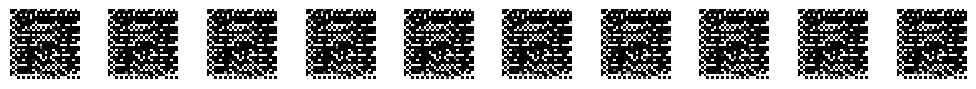

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
101/10000 [D loss: 0.8480855226516724 | D accuracy: 35.38105010986328] [G loss: 0.45258083939552307]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
102/10000 [D loss: 0.8492306470870972 | D accuracy: 35.371253967285156] [G loss: 0.4514610767364502]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
103/10000 [D loss: 0.8502962589263916 | D accuracy: 35.36165237426758] [G loss: 0.45033031702041626]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
104/10000 [D loss: 0.8514121770858765 | D accuracy: 35.292564392089844] [G loss: 0.44924625754356384]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step
105/10000 [D loss: 0.8525228500366211 | D accuracy: 35.26911163330078] [G loss: 0.448117733001709]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step
106/10000 [D loss: 0.8535815477371216 | D accuracy: 35.290008544921875] [G loss: 0.4471209943294525]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
107/10000 [D loss: 0.8545635938644409 | D accuracy: 35.310516357421875] [G loss: 0.44602182507514954]
1/1 ━━━━━━━━━━━━━━━━

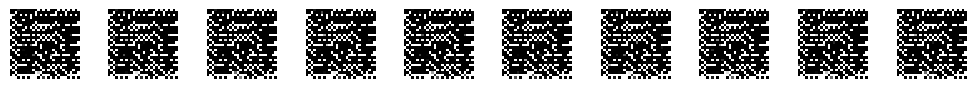

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
201/10000 [D loss: 0.9122357368469238 | D accuracy: 35.05271530151367] [G loss: 0.3890732526779175]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
202/10000 [D loss: 0.9126055240631104 | D accuracy: 35.0262565612793] [G loss: 0.3887081444263458]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step
203/10000 [D loss: 0.9129601716995239 | D accuracy: 35.01538848876953] [G loss: 0.3883456289768219]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step
204/10000 [D loss: 0.9132817387580872 | D accuracy: 35.00463104248047] [G loss: 0.38796326518058777]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
205/10000 [D loss: 0.9136126041412354 | D accuracy: 34.978790283203125] [G loss: 0.38760513067245483]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
206/10000 [D loss: 0.9140386581420898 | D accuracy: 34.93052291870117] [G loss: 0.3872191905975342]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
207/10000 [D loss: 0.9143852591514587 | D accuracy: 34.94289016723633] [G loss: 0.3868732154369354]
1/1 ━━━━━━━━━━━━━━━━━━━━ 

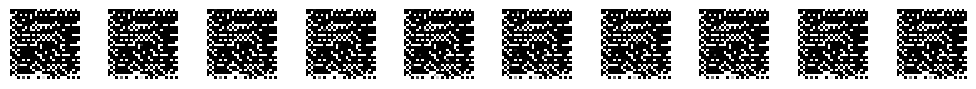

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step
301/10000 [D loss: 0.9377478361129761 | D accuracy: 34.7815055847168] [G loss: 0.36491870880126953]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
302/10000 [D loss: 0.9379597902297974 | D accuracy: 34.7801628112793] [G loss: 0.3647572100162506]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
303/10000 [D loss: 0.9381483197212219 | D accuracy: 34.778831481933594] [G loss: 0.3645899295806885]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
304/10000 [D loss: 0.9383037686347961 | D accuracy: 34.777503967285156] [G loss: 0.3644168972969055]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
305/10000 [D loss: 0.9384780526161194 | D accuracy: 34.79151916503906] [G loss: 0.3642357587814331]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
306/10000 [D loss: 0.9386329054832458 | D accuracy: 34.81563186645508] [G loss: 0.36407706141471863]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
307/10000 [D loss: 0.9388014078140259 | D accuracy: 34.8141975402832] [G loss: 0.3639283776283264]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0

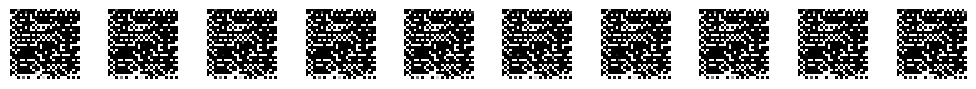

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
401/10000 [D loss: 0.9561043977737427 | D accuracy: 34.707542419433594] [G loss: 0.34869787096977234]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
402/10000 [D loss: 0.9562808275222778 | D accuracy: 34.71059799194336] [G loss: 0.34854963421821594]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
403/10000 [D loss: 0.9564282298088074 | D accuracy: 34.717506408691406] [G loss: 0.3484102487564087]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
404/10000 [D loss: 0.9565832614898682 | D accuracy: 34.72052001953125] [G loss: 0.34826403856277466]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
405/10000 [D loss: 0.9567614793777466 | D accuracy: 34.692710876464844] [G loss: 0.34811756014823914]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
406/10000 [D loss: 0.956929087638855 | D accuracy: 34.69961166381836] [G loss: 0.3479851186275482]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
407/10000 [D loss: 0.9571039080619812 | D accuracy: 34.698822021484375] [G loss: 0.34786200523376465]
1/1 ━━━━━━━━━━━━━━━

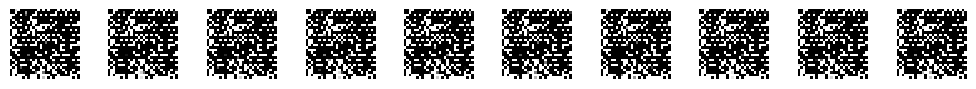

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
501/10000 [D loss: 0.9755233526229858 | D accuracy: 34.728458404541016] [G loss: 0.33320266008377075]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
502/10000 [D loss: 0.9757549166679382 | D accuracy: 34.730865478515625] [G loss: 0.3330279588699341]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
503/10000 [D loss: 0.975986659526825 | D accuracy: 34.7425651550293] [G loss: 0.3328627943992615]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
504/10000 [D loss: 0.9762285351753235 | D accuracy: 34.75421905517578] [G loss: 0.33270975947380066]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
505/10000 [D loss: 0.9764801859855652 | D accuracy: 34.74420166015625] [G loss: 0.332536906003952]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
506/10000 [D loss: 0.9766935110092163 | D accuracy: 34.75271987915039] [G loss: 0.3323729932308197]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
507/10000 [D loss: 0.9769150018692017 | D accuracy: 34.751976013183594] [G loss: 0.3322083353996277]
1/1 ━━━━━━━━━━━━━━━━━━━━ 

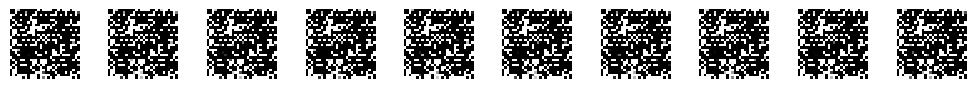

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
601/10000 [D loss: 0.9968968629837036 | D accuracy: 34.64115524291992] [G loss: 0.318167507648468]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
602/10000 [D loss: 0.9971045255661011 | D accuracy: 34.64071273803711] [G loss: 0.3180290162563324]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
603/10000 [D loss: 0.9973108768463135 | D accuracy: 34.645450592041016] [G loss: 0.3178972899913788]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
604/10000 [D loss: 0.9975266456604004 | D accuracy: 34.63725280761719] [G loss: 0.3177570402622223]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step
605/10000 [D loss: 0.997739315032959 | D accuracy: 34.62392044067383] [G loss: 0.3176206946372986]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step
606/10000 [D loss: 0.9979532957077026 | D accuracy: 34.61836242675781] [G loss: 0.3174874484539032]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
607/10000 [D loss: 0.9981640577316284 | D accuracy: 34.5999641418457] [G loss: 0.31734567880630493]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

KeyboardInterrupt: 

In [21]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

# Load and prepare the MNIST dataset
(x_train, _), (_, _) = mnist.load_data()
x_train = x_train / 127.5 - 1.0  # Normalize to [-1, 1]
x_train = np.expand_dims(x_train, axis=-1)  # Add channel dimension (28, 28, 1)

# Label information for conditioning
num_classes = 10  # 10 digits in MNIST

# The generator model
def build_generator(latent_dim):
    model = models.Sequential()

    # Dense layer to fully connect, reshaped to 7x7x256 tensor
    model.add(layers.Dense(7*7*256, activation='relu', input_dim=latent_dim))
    model.add(layers.Reshape((7, 7, 256)))

    # Transpose Convolutional layers (to upsample the image)
    model.add(layers.Conv2DTranspose(128, kernel_size=4, strides=2, padding='same', activation='relu'))
    model.add(layers.Conv2DTranspose(64, kernel_size=4, strides=2, padding='same', activation='relu'))

    # Output layer (final image generation)
    model.add(layers.Conv2DTranspose(1, kernel_size=7, activation='tanh', padding='same'))

    return model

# The discriminator model
def build_discriminator():
    model = models.Sequential()

    # Convolutional layers to classify real or fake images
    model.add(layers.Conv2D(64, kernel_size=3, strides=2, padding='same', input_shape=(28, 28, 1)))
    model.add(layers.LeakyReLU(alpha=0.2))
    model.add(layers.Dropout(0.3))

    model.add(layers.Conv2D(128, kernel_size=3, strides=2, padding='same'))
    model.add(layers.LeakyReLU(alpha=0.2))
    model.add(layers.Dropout(0.3))

    model.add(layers.Flatten())
    model.add(layers.Dense(1, activation='sigmoid'))

    return model

# The combined model for training both networks
def build_cgan(generator, discriminator):
    # Freeze the discriminator when training the generator
    discriminator.trainable = False
    model = models.Sequential([generator, discriminator])
    return model

# Function to compile models
def compile_models(generator, discriminator, cgan):
    # Discriminator loss and optimizer
    discriminator.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    # CGAN loss and optimizer
    cgan.compile(optimizer='adam', loss='binary_crossentropy')

# Training the cGAN model
def train(generator, discriminator, cgan, epochs, batch_size, latent_dim, data):
    half_batch = batch_size // 2

    for epoch in range(epochs):
        # Select a random batch of real images and labels
        idx = np.random.randint(0, data.shape[0], half_batch)
        real_images = data[idx]
        real_labels = np.ones((half_batch, 1))  # Real images labeled as 1

        # Generate a batch of fake images
        noise = np.random.normal(0, 1, (half_batch, latent_dim))
        fake_images = generator.predict(noise)
        fake_labels = np.zeros((half_batch, 1))  # Fake images labeled as 0

        # Train the discriminator (real images = 1, fake images = 0)
        d_loss_real = discriminator.train_on_batch(real_images, real_labels)
        d_loss_fake = discriminator.train_on_batch(fake_images, fake_labels)
        d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)

        # Train the generator via the cGAN model (generate fake images to fool the discriminator)
        noise = np.random.normal(0, 1, (batch_size, latent_dim))
        valid_labels = np.ones((batch_size, 1))  # Want the discriminator to classify as real
        g_loss = cgan.train_on_batch(noise, valid_labels)

        # Print the progress
        print(f"{epoch}/{epochs} [D loss: {d_loss[0]} | D accuracy: {100 * d_loss[1]}] [G loss: {g_loss}]")

        # Save and plot the generated images every few epochs
        if epoch % 100 == 0:
            plot_generated_images(epoch, generator)

# Function to plot generated images
def plot_generated_images(epoch, generator, examples=10, dim=(1, 10), figsize=(10, 1)):
    noise = np.random.normal(0, 1, (examples, 100))
    generated_images = generator.predict(noise)
    plt.figure(figsize=figsize)
    for i in range(examples):
        plt.subplot(dim[0], dim[1], i + 1)
        plt.imshow(generated_images[i, :, :, 0], interpolation='nearest', cmap='gray')
        plt.axis('off')
    plt.tight_layout()
    plt.savefig(f"generated_image_epoch_{epoch}.png")
    plt.show()

# Initialize and compile models
latent_dim = 100
generator = build_generator(latent_dim)
discriminator = build_discriminator()
cgan = build_cgan(generator, discriminator)

compile_models(generator, discriminator, cgan)

# Train the model
train(generator, discriminator, cgan, epochs=10000, batch_size=64, latent_dim=latent_dim, data=x_train)


In [1]:
import random
import math

# Define the 2D space as a square (0,0) to (10,10)
CAN_SPACE_SIZE = 10

class Node:
    def __init__(self, name, x=None, y=None):
        self.name = name
        self.x = x if x is not None else random.uniform(0, CAN_SPACE_SIZE)
        self.y = y if y is not None else random.uniform(0, CAN_SPACE_SIZE)

    def distance_to(self, x, y):
        return math.hypot(self.x - x, self.y - y)

    def __repr__(self):
        return f"Node({self.name}, x={self.x:.2f}, y={self.y:.2f})"

class CAN:
    def __init__(self):
        self.nodes = []

    def add_node(self, node):
        self.nodes.append(node)
        print(f"Added {node}")

    def route(self, target_x, target_y):
        print(f"\nRouting to target: ({target_x:.2f}, {target_y:.2f})")
        current = min(self.nodes, key=lambda n: n.distance_to(target_x, target_y))
        print(f"Nearest node to target is: {current}")
        return current

# Simulate CAN usage
can_network = CAN()

# Add some nodes
for i in range(5):
    node = Node(f"N{i}")
    can_network.add_node(node)

# Route a message to a random point
target_x, target_y = random.uniform(0, CAN_SPACE_SIZE), random.uniform(0, CAN_SPACE_SIZE)
can_network.route(target_x, target_y)


Added Node(N0, x=9.10, y=8.92)
Added Node(N1, x=0.11, y=0.20)
Added Node(N2, x=2.01, y=3.02)
Added Node(N3, x=3.46, y=8.82)
Added Node(N4, x=9.03, y=8.90)

Routing to target: (0.33, 7.92)
Nearest node to target is: Node(N3, x=3.46, y=8.82)


Node(N3, x=3.46, y=8.82)